In [12]:
import dill
import sys
import os
sys.path.append('../')
from utils.helper_functions import get_color

import matplotlib
matplotlib.rcParams['pgf.texsystem'] = 'pdflatex'
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

plt.rcParams.update(
        {
            "text.usetex": False,
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
            "font.serif": ["Arial"],
            "mathtext.fontset": "custom",
            "mathtext.sf": "Arial",
            "mathtext.rm": "Arial",
            "mathtext.it": "Arial:italic",
            "mathtext.bf": "Arial:bold",
            "pdf.fonttype": 42,
        }
    )
 

from utils.feature_configuration import target_names, feature_list_FR_price, feature_list_FR_export, feature_list_ES_price, paper_rename_dict_inverse

In [13]:
figure_folder = "../figs_for_paper/"
if os.path.exists(figure_folder):
    print(f"Figure folder '{figure_folder}' already exists.")
else:
    os.makedirs(figure_folder)
    print(f"Figure folder '{figure_folder}' created.")

Figure folder '../figs_for_paper/' already exists.


In [14]:
dict_r2_scores = {}
for target in target_names:
    with open('../credit_flow/r2_scores_{}.pkl'.format(target), 'rb') as file:
        r2_scores = dill.load(file)
    dict_r2_scores[target] = r2_scores

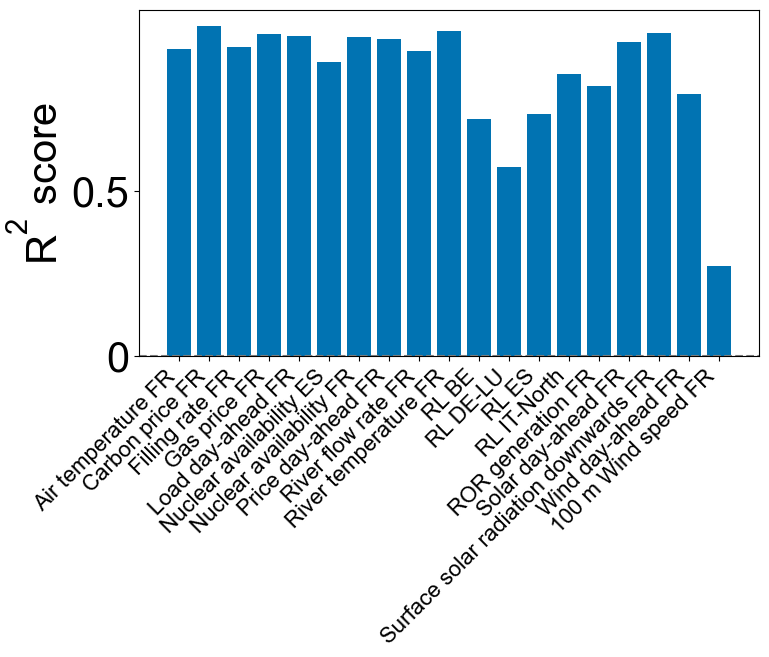

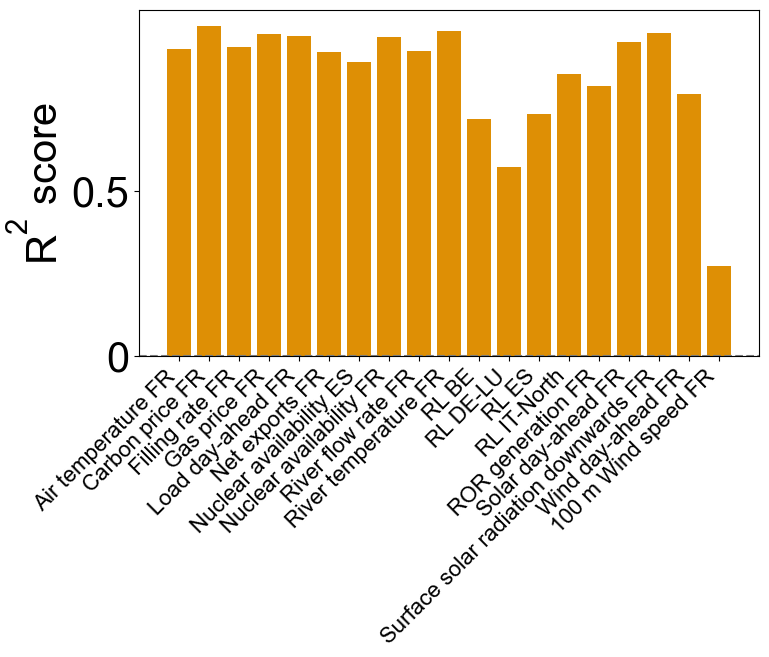

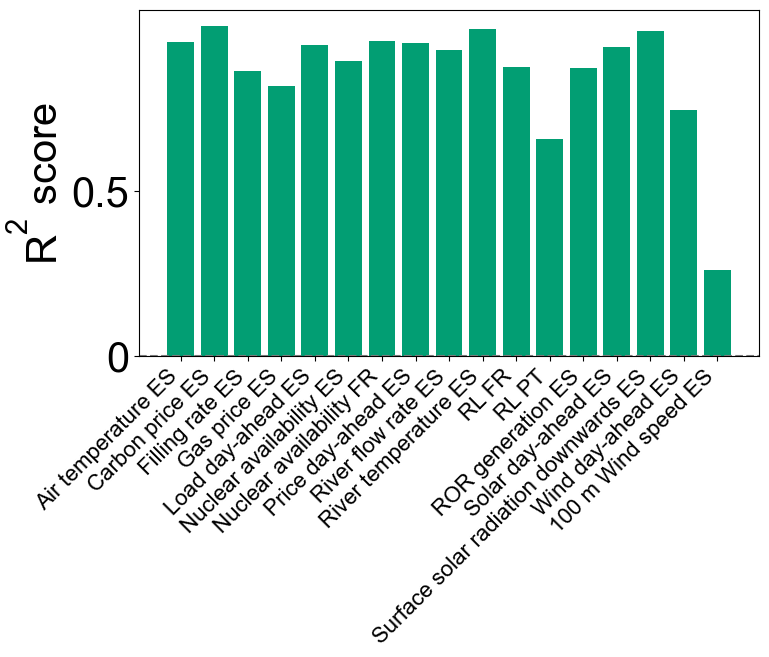

In [ ]:
# add the r2-scores of the final model, see file calculate_model_performance.ipynb for the calculation of these scores
# for simplicity, we just add them manually here
dict_r2_scores['FR_price'].update({'FR_price': 0.96})
dict_r2_scores['FR_export'].update({'FR_export': 0.92})
dict_r2_scores['ES_price'].update({'ES_price': 0.95})

cut_off_dict = {}
for i,target in enumerate(dict_r2_scores.keys()):
    fig,ax = plt.subplots(1,1,figsize=(8, 4.5))
    if target == 'FR_price':
        feature_list = feature_list_FR_price
    elif target == 'FR_export':
        feature_list = feature_list_FR_export
    else:
        feature_list = feature_list_ES_price
    keys = [paper_rename_dict_inverse[f] for f in feature_list]
    ax.bar(feature_list, [dict_r2_scores[target][key] for key in keys], color = get_color(target))
    ax.axhline(0, color='grey', linestyle='--')
    ax.set_yticks([0,0.5], labels = ['0', '0.5'], fontsize = 30)
    ax.set_xticks(feature_list, labels = feature_list, rotation=45, ha='right', fontsize = 16)
    ax.set_ylabel(r'$\text{R}^2$ score', fontsize = 30)

    fig.savefig('../figs_for_paper/r2_scores_gbt_{}.pdf'.format(target), bbox_inches='tight')